# AnyUp3D × Video Swin Transformer — End-to-End Test

**Goal.** Swap the VideoMAE backbone for **Swin3D-T** and test whether AnyUp3D can still upsample
the spatiotemporal feature map cleanly (a) spatially — per-frame quality — and (b) temporally — frames evolve smoothly.

**Pipeline**
1. Upload a video, resample to 16 frames at 224×224.
2. Run Swin3D-T, tap the output of **stage 3** (14×14, C=384) or **stage 4** (7×7, C=768).
3. Build a guide video at T'=8 (Swin's tubelet=2 halves time).
4. Feed both to AnyUp3D → features at 224×224, temporal length T'=8.
5. Joint PCA + cosine checks + 3-column comparison video.

**You'll need:** `anyup_multi_backbone.pth` (the official 2D AnyUp release). Upload into `/content/anyup/` after Cell 1.


In [2]:

import os
# ── evaluation package (also needed for Exp 3 J&F scoring) ───────────────────
if not os.path.exists("/content/davis2017-evaluation"):
    subprocess.run([
        "git", "clone",
        "https://github.com/davisvideochallenge/davis2017-evaluation.git",
        "/content/davis2017-evaluation"
    ], check=True)
    subprocess.run(
        ["python", "setup.py", "install"],
        cwd="/content/davis2017-evaluation", check=True
    )
    print("DAVIS evaluation package installed")
else:
    print("DAVIS evaluation package already present")

# ── dataset download ──────────────────────────────────────────────────────────
DAVIS_ZIP = "/content/DAVIS-2017-trainval-480p.zip"
DAVIS_URL = "https://data.davis-challenge.ch/DAVIS-2017-trainval-480p.zip"

if not os.path.exists(os.path.join(DAVIS_ROOT, "ImageSets")):
    print(f"Downloading DAVIS 2017...")
    result = subprocess.run([
        "wget", "-q", "--no-check-certificate",   # ← fixes most SSL failures on academic servers
        DAVIS_URL, "-O", DAVIS_ZIP
    ], capture_output=True, text=True)

    if result.returncode != 0 or not os.path.exists(DAVIS_ZIP):
        print("⚠  wget failed. See manual fallback instructions above.")
        print("stderr:", result.stderr[:500])
    else:
        print("Extracting...")
        subprocess.run(["unzip", "-q", DAVIS_ZIP, "-d", "/content/"], check=True)
        print("Done.")
else:
    print(f"DAVIS already present at {DAVIS_ROOT}")

# ── clip loader ───────────────────────────────────────────────────────────────
def load_clip_paths(davis_root, split="val"):
    val_txt    = Path(davis_root) / "ImageSets" / "2017" / f"{split}.txt"
    clip_names = [l.strip() for l in val_txt.read_text().splitlines() if l.strip()]

    clips = {}
    for name in clip_names:
        frame_dir  = Path(davis_root) / "JPEGImages" / "480p" / name
        all_frames = sorted(frame_dir.glob("*.jpg"))
        sampled    = all_frames[::FRAME_STEP]   # 2fps; step set by FRAME_STEP in Cell 0
        if len(sampled) < 2:
            print(f"  skip {name} — only {len(sampled)} sampled frame(s)")
            continue
        clips[name] = [str(p) for p in sampled]

    print(f"\nLoaded {len(clips)} clips")
    for name, paths in clips.items():
        print(f"  {name}: T={len(paths)}")
    return clips

if os.path.exists(os.path.join(DAVIS_ROOT, "ImageSets")):
    clips = load_clip_paths(DAVIS_ROOT)
else:
    print("DAVIS not found — set DAVIS_ROOT in Cell 0 and re-run this cell.")
    clips = {}

NameError: name 'subprocess' is not defined

In [1]:
# ============================================================
# Cell 1 — Install dependencies + clone YOUR fork
# ============================================================
!git clone https://github.com/mu-az88/anyup.git
%cd anyup
!pip install -e . --quiet
!pip install matplotlib scikit-learn --quiet
!apt-get install -y ffmpeg --quiet

# Sanity: torchvision must include swin3d_t (v0.14+). Colab is fine.
import torchvision, torch
print(f"torch={torch.__version__}, torchvision={torchvision.__version__}")
from torchvision.models.video import swin3d_t  # must import cleanly
print("swin3d_t available ✓")


Cloning into 'anyup'...
remote: Enumerating objects: 399, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 399 (delta 89), reused 138 (delta 60), pack-reused 222 (from 1)
Receiving objects: 100% (399/399), 17.68 MiB | 17.00 MiB/s, done.
Resolving deltas: 100% (200/200), done.
/content/anyup
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.1 MB/s eta 0:00:00
  Building editable for anyup (pyproject.toml) ... done
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
torch=2.10.0+cu128, torchvision=0.25.0+cu128
swin3d_t available ✓


In [1]:

# ============================================================
# Cell 2 — Imports & device
# ============================================================
import os, glob, subprocess
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
TARGET_SIZE   = 224                        # ↑ to 256/384 for sharper output — also changes Swin stage3/4 spatial (÷16, ÷32) and q_chunk size in Cell 8
T_INPUT       = 16                         # frames fed to Swin3D; must be even (tubelet=2). T_PRIME = T_INPUT // 2 throughout
T_PRIME       = T_INPUT // 2               # depends on T_INPUT — also drives guide-video T in Cell 6 and all T' assertions


Using device: cuda


## Where to put your trained 3D weights

You already trained AnyUp3D — the checkpoint lives in Google Drive at `anyup3d/checkpoints/run_01/`.
The cleanest path is to **mount Drive** and point directly at the checkpoint file.

Cell 3 below mounts Drive and lets you pick which checkpoint step to load.


In [3]:
# ============================================================
# Cell 3 — Mount Google Drive and locate your trained 3D checkpoint
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Path to your training run. Change `run_01` if you've launched more runs since.
CKPT_DIR = "/content/drive/MyDrive/anyup3d/checkpoints/run_01"

assert os.path.isdir(CKPT_DIR), (
    f"Not found: {CKPT_DIR}\n"
    f"   -> Adjust CKPT_DIR above. If your Drive root is different, check the Files panel."
)

# Manually set the path to your desired 3D weights file.
WEIGHTS_3D = "/content/drive/MyDrive/anyup3d/checkpoints/run_01/anyup3d_step10000.pth" # <--- Set your desired path here
print(f"\nWill load: {WEIGHTS_3D}")


Mounted at /content/drive

Will load: /content/drive/MyDrive/anyup3d/checkpoints/run_01/anyup3d_step10000.pth


Saving aigc_1.mp4 to aigc_1.mp4
Uploaded: aigc_1.mp4
Total frames extracted: 47
Sampled 16 frames at indices: [np.int64(0), np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30), np.int64(33), np.int64(36), np.int64(39), np.int64(42), np.int64(46)]
frames tensor: torch.Size([16, 3, 224, 224])


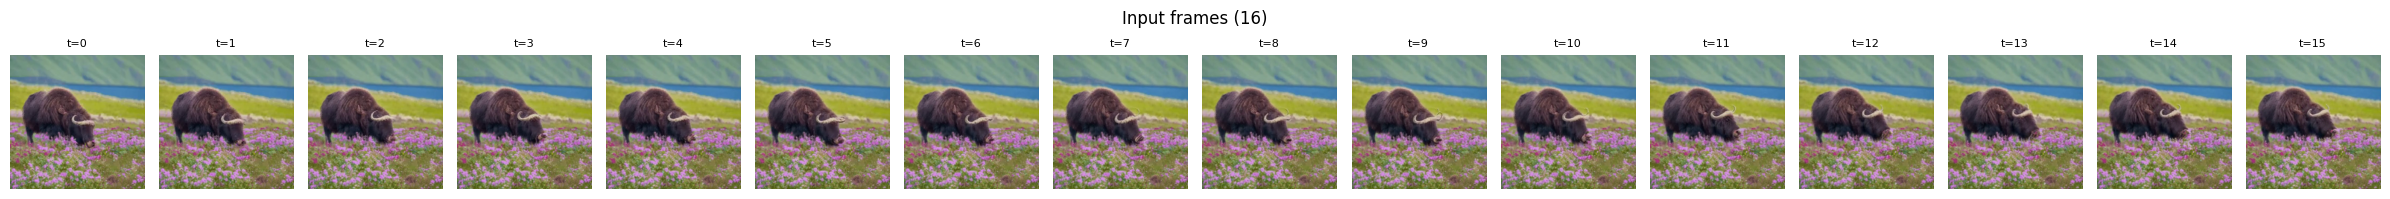

In [4]:
# ============================================================
# Cell 4 — Upload a video and extract T_INPUT frames
# ============================================================
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Uploaded: {video_path}")

frames_dir = "/tmp/anyup_frames"
os.makedirs(frames_dir, exist_ok=True)
for f in glob.glob(f"{frames_dir}/*.png"):
    os.remove(f)

# Step 1: dump every frame — no filter expression, works for any video length
result = subprocess.run(
    ["ffmpeg", "-y", "-i", video_path, "-vsync", "0",
     f"{frames_dir}/frame_%04d.png"],
    capture_output=True,
)
all_paths = sorted(glob.glob(f"{frames_dir}/frame_*.png"))
N_total = len(all_paths)
assert N_total > 0, f"ffmpeg produced no frames. stderr:\n{result.stderr.decode()}"
print(f"Total frames extracted: {N_total}")

# Step 2: pick T_INPUT evenly-spaced indices in Python
indices = np.linspace(0, N_total - 1, T_INPUT, dtype=int)
frame_paths = [all_paths[i] for i in indices]   # exactly T_INPUT paths
print(f"Sampled {len(frame_paths)} frames at indices: {list(indices)}")

def load_frame(path):
    img = Image.open(path).convert("RGB").resize((TARGET_SIZE, TARGET_SIZE), Image.BICUBIC)
    t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    return (t - IMAGENET_MEAN) / IMAGENET_STD

frames = torch.stack([load_frame(p) for p in frame_paths])  # (T_INPUT, 3, H, W)
print(f"frames tensor: {frames.shape}")

# Preview
fig, axes = plt.subplots(1, T_INPUT, figsize=(1.5*T_INPUT, 2))
for i, ax in enumerate(axes):
    vis = (frames[i].permute(1,2,0) * IMAGENET_STD.squeeze() + IMAGENET_MEAN.squeeze()).clamp(0,1)
    ax.imshow(vis.numpy()); ax.axis("off"); ax.set_title(f"t={i}", fontsize=8)
plt.suptitle(f"Input frames ({T_INPUT})"); plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# Cell 5 — Load Swin3D-T and build a stage-selectable extractor
# ============================================================
from torchvision.models.video import swin3d_t, Swin3D_T_Weights

STAGE = 3  # 3 → (14×14, C=384)  |  4 → (7×7, C=768)

print("Loading Swin3D-T (Kinetics-400 pretrained)...")
swin = swin3d_t(weights=Swin3D_T_Weights.KINETICS400_V1).to(device).eval()
print(f"  params: {sum(p.numel() for p in swin.parameters())/1e6:.1f}M")

# Layout from your version:
#   [0] Sequential  ← stage 1 blocks
#   [1] PatchMerging
#   [2] Sequential  ← stage 2 blocks
#   [3] PatchMerging
#   [4] Sequential  ← stage 3 blocks   → (B, 384, T', 14, 14)
#   [5] PatchMerging
#   [6] Sequential  ← stage 4 blocks   → (B, 768, T',  7,  7)
STAGE_HOOK_IDX = {1: 0, 2: 2, 3: 4, 4: 6}
STAGE_DIM      = {1: 96, 2: 192, 3: 384, 4: 768}
STAGE_SPATIAL  = {1: 56, 2: 28, 3: 14, 4: 7}

hook_idx = STAGE_HOOK_IDX[STAGE]
print(f"Stage {STAGE} → hooking swin.features[{hook_idx}]")

class Swin3DFeatureExtractor(nn.Module):
    def __init__(self, backbone, hook_idx):
        super().__init__()
        self.backbone = backbone
        self._captured = None
        backbone.features[hook_idx].register_forward_hook(self._hook)

    def _hook(self, module, input, output):
        # output is channels-last: (B, T', H', W', C)
        self._captured = output.permute(0, 4, 1, 2, 3).contiguous()

    @torch.no_grad()
    def forward(self, x):
        self.backbone(x)
        return self._captured

extractor = Swin3DFeatureExtractor(swin, hook_idx).to(device).eval()

# Shape probe
with torch.no_grad():
    probe = torch.zeros(1, 3, T_INPUT, TARGET_SIZE, TARGET_SIZE, device=device)
    probe_out = extractor(probe)

expected = (1, STAGE_DIM[STAGE], T_PRIME, STAGE_SPATIAL[STAGE], STAGE_SPATIAL[STAGE])
print(f"Stage {STAGE} output: {tuple(probe_out.shape)}")
assert tuple(probe_out.shape) == expected, f"Expected {expected}, got {tuple(probe_out.shape)}"
print("Stage indexing verified")

Loading Swin3D-T (Kinetics-400 pretrained)...
  params: 28.2M
Stage 3 → hooking swin.features[4]
Stage 3 output: (1, 384, 8, 14, 14)
Stage indexing verified


In [12]:
# ============================================================
# Cell 6 — Run Swin3D feature extraction on the real video
# ============================================================
video_in = frames.permute(1, 0, 2, 3).unsqueeze(0).to(device)  # (1, 3, T_INPUT, H, W)
print(f"Swin3D input : {tuple(video_in.shape)}")

with torch.no_grad():
    lr_features_3d = extractor(video_in)    # (1, C_stage, T', h, w)
print(f"Swin3D output: {tuple(lr_features_3d.shape)}  ← LR features for AnyUp3D")

C_STAGE, _, HS, WS = lr_features_3d.shape[1], lr_features_3d.shape[2], lr_features_3d.shape[3], lr_features_3d.shape[4]
# (HS, WS) drive all downstream memory — also see q_chunk_size in Cell 8 and PCA flatten in Cell 9


Swin3D input : (1, 3, 16, 224, 224)
Swin3D output: (1, 384, 8, 14, 14)  ← LR features for AnyUp3D


Guide video (for AnyUp3D): (1, 3, 8, 224, 224)
LR features (for AnyUp3D): (1, 384, 8, 14, 14)


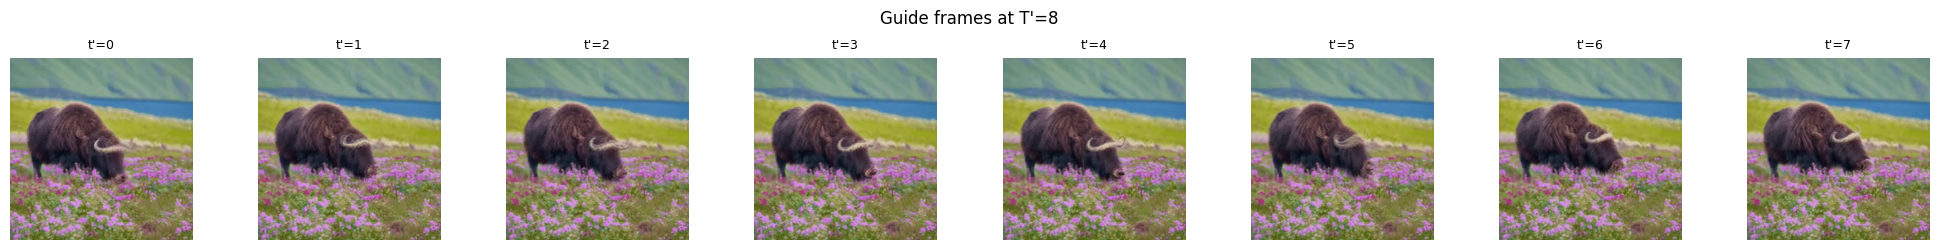

In [13]:
# ============================================================
# Cell 7 — Build the guide video at T'=8 (matches feature T)
# ============================================================
# AnyUp3D needs the guide video to share the feature map's temporal axis.
# Swin's tubelet=2 collapsed T_INPUT→T_PRIME, so downsample the guide in time too.

guide_video = frames.permute(1, 0, 2, 3).unsqueeze(0).float()    # (1, 3, T_INPUT, H, W)
guide_video = F.interpolate(
    guide_video,
    size=(T_PRIME, TARGET_SIZE, TARGET_SIZE),                    # → (1, 3, T_PRIME, 224, 224)
    mode="trilinear", align_corners=False,
).to(device)

print(f"Guide video (for AnyUp3D): {tuple(guide_video.shape)}")
print(f"LR features (for AnyUp3D): {tuple(lr_features_3d.shape)}")

# Preview the 8 guide frames
g = guide_video[0].permute(1, 0, 2, 3).cpu()                     # (T_PRIME, 3, H, W)
fig, axes = plt.subplots(1, T_PRIME, figsize=(2.5*T_PRIME, 2.5))
for i, ax in enumerate(axes):
    vis = (g[i].permute(1,2,0) * IMAGENET_STD.squeeze() + IMAGENET_MEAN.squeeze()).clamp(0,1)
    ax.imshow(vis.numpy()); ax.axis("off"); ax.set_title(f"t'={i}", fontsize=9)
plt.suptitle(f"Guide frames at T'={T_PRIME}"); plt.tight_layout(); plt.show()


In [14]:
# ============================================================
# Cell 8 - Instantiate AnyUp3D and load your trained 3D weights
# ============================================================
from anyup.model import AnyUp
from anyup.modules import create_coordinates_3d  # noqa: F401
import __main__

# TStage was defined in __main__ of train.py — stub it here so unpickling can find it.
class TStage:
    def __init__(self, *args, **kwargs):
        self.__dict__.update(kwargs)
    def __repr__(self):
        return f"TStage({self.__dict__})"

__main__.TStage = TStage  # inject into __main__ so pickle's find_class() resolves it

model = AnyUp(
    input_dim=3,
    qk_dim=128,
    kernel_size=1,
    kernel_size_lfu=5,
    window_ratio=0.1,
    num_heads=4,
    window_t= None,
    t_k=1,
).to(device).eval()

total = sum(p.numel() for p in model.parameters())
print(f"AnyUp3D parameters: {total:,}")

# --- Load the trained 3D checkpoint ---
ckpt = torch.load(WEIGHTS_3D, map_location="cpu", weights_only=False)

# Unwrap the training engine's save format
if isinstance(ckpt, dict):
    if "model" in ckpt:
        sd = ckpt["model"]
    elif "state_dict" in ckpt:
        sd = ckpt["state_dict"]
    elif "ema" in ckpt:
        sd = ckpt["ema"]
    else:
        sd = ckpt
    for k in ("step", "epoch", "loss", "iteration", "global_step"):
        if k in ckpt:
            print(f"  checkpoint {k}: {ckpt[k]}")
else:
    sd = ckpt

# Strip DDP 'module.' prefix if training was distributed
sd = {k.replace("module.", "", 1) if k.startswith("module.") else k: v for k, v in sd.items()}

missing, unexpected = model.load_state_dict(sd, strict=False)
print(f"Loaded weights from {os.path.basename(WEIGHTS_3D)}")
print(f"  missing    : {len(missing)} keys")
print(f"  unexpected : {len(unexpected)} keys")
if missing:
    print(f"  (first 5 missing)   : {missing[:5]}")
if unexpected:
    print(f"  (first 5 unexpected): {unexpected[:5]}")

if len(missing) == 0 and len(unexpected) == 0:
    print("\nStrict match - all keys loaded cleanly.")
else:
    print("\nWARNING: strict load failed. Confirm AnyUp(...) args match your training cfg.")

AnyUp3D parameters: 878,208
  checkpoint global_step: 10000
Loaded weights from anyup3d_step10000.pth
  missing    : 73 keys
  unexpected : 7 keys
  (first 5 missing)   : ['image_encoder.0.conv.weight', 'image_encoder.1.block.0.weight', 'image_encoder.1.block.0.bias', 'image_encoder.1.block.2.conv.weight', 'image_encoder.1.block.3.weight']
  (first 5 unexpected): ['anyup', 'optimizer', 'scheduler', 'global_step', 'data_epoch']



In [9]:
# ============================================================
# Cell 9 — AnyUp3D forward pass
# ============================================================
with torch.no_grad():
    hr_features_3d = model(
        guide_video,                          # (1, 3, T', 224, 224) — see Cell 7
        lr_features_3d,                       # (1, C, T',  h,   w)  — see Cell 6
        output_size=(TARGET_SIZE, TARGET_SIZE),
        q_chunk_size=512,                     # ↓ to 256/128 if OOM — only affects throughput, not results
    )

print(f"AnyUp3D output: {tuple(hr_features_3d.shape)}  ← should be (1, {C_STAGE}, {T_PRIME}, {TARGET_SIZE}, {TARGET_SIZE})")
hr_features_3d = hr_features_3d.cpu()
lr_features_cpu = lr_features_3d.cpu()


AnyUp3D output: (1, 768, 8, 224, 224)  ← should be (1, 768, 8, 224, 224)


Fitting PCA on LR features...
Fitting PCA on HR features...


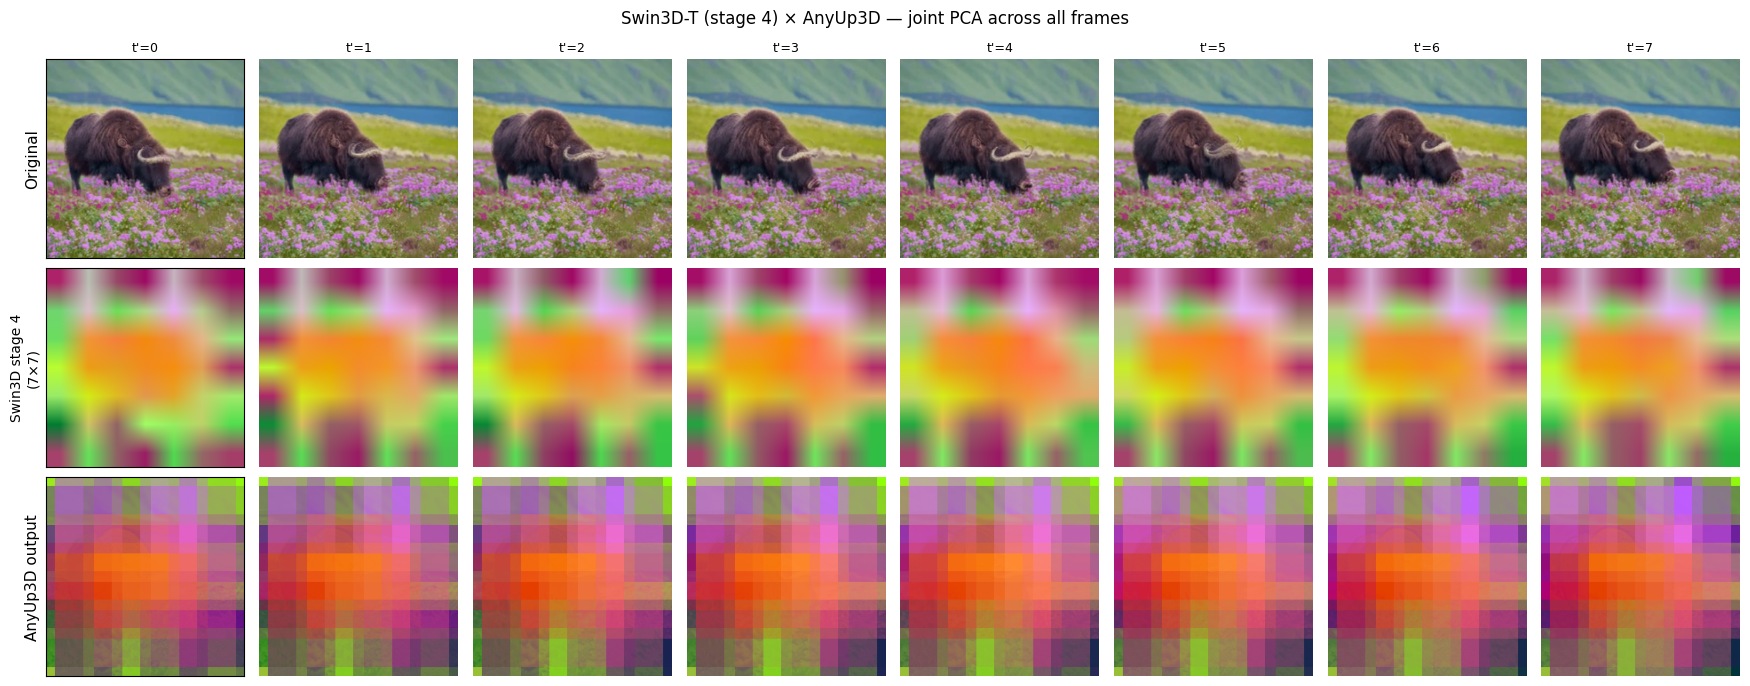

In [10]:
# ============================================================
# Cell 10 — PCA visualization (Original | LR | HR)
# ============================================================
# Joint PCA across all T'*H*W tokens so a single RGB mapping applies across frames
# (this is what makes temporal consistency visually readable).

lr_all = lr_features_cpu[0].permute(1, 0, 2, 3)   # (T', C, h,  w)
hr_all = hr_features_3d[0].permute(1, 0, 2, 3)    # (T', C, H,  W)

# Guide frames (already at T') for the top row
display_frames = guide_video[0].permute(1, 0, 2, 3).cpu()  # (T', 3, H, W)

def fit_pca_jointly(feat_t_c_h_w):
    T, C, H, W = feat_t_c_h_w.shape
    flat = feat_t_c_h_w.permute(0, 2, 3, 1).reshape(-1, C).numpy()   # (T*H*W, C)
    pcs  = PCA(n_components=3).fit_transform(flat)
    pcs -= pcs.min(0); pcs /= (pcs.max(0) + 1e-6)
    return pcs.reshape(T, H, W, 3)

print("Fitting PCA on LR features...")
lr_pca = fit_pca_jointly(lr_all)                                     # (T', h, w, 3)
print("Fitting PCA on HR features...")
hr_pca = fit_pca_jointly(hr_all)                                     # (T', H, W, 3)

fig, axes = plt.subplots(3, T_PRIME, figsize=(2.2*T_PRIME, 7))
for i in range(T_PRIME):
    # Row 0 — original
    vis = (display_frames[i].permute(1,2,0) * IMAGENET_STD.squeeze() + IMAGENET_MEAN.squeeze()).clamp(0,1).numpy()
    axes[0, i].imshow(vis);                    axes[0, i].axis("off")
    axes[0, i].set_title(f"t'={i}", fontsize=9)

    # Row 1 — LR (nearest-neighbor upsample so the feature grid is visible)
    # was: lr_up = np.kron(lr_pca[i], np.ones(...))  ← nearest-neighbor, looks artificially bad
    lr_up_tensor = torch.from_numpy(lr_pca[i]).permute(2, 0, 1).unsqueeze(0).float()  # (1, 3, h, w)
    lr_up = F.interpolate(lr_up_tensor, size=(TARGET_SIZE, TARGET_SIZE), mode="bilinear", align_corners=False)
    lr_up = lr_up.squeeze(0).permute(1, 2, 0).numpy()
    axes[1, i].imshow(lr_up)
    axes[1, i].axis("off")

    # Row 2 — HR (AnyUp3D output)
    axes[2, i].imshow(hr_pca[i]);              axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original",            fontsize=11)
axes[1, 0].set_ylabel(f"Swin3D stage {STAGE}\n({lr_all.shape[2]}×{lr_all.shape[3]})", fontsize=10)
axes[2, 0].set_ylabel("AnyUp3D output",      fontsize=11)
for ax in axes[:, 0]: ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"Swin3D-T (stage {STAGE}) × AnyUp3D — joint PCA across all frames", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================
# Cell 11 — Sanity checks
# ============================================================
print("=== Shape checks ===")
assert hr_features_3d.shape == (1, C_STAGE, T_PRIME, TARGET_SIZE, TARGET_SIZE), (
    f"Bad shape: {hr_features_3d.shape}"
)
print(f"✓ Output shape: {tuple(hr_features_3d.shape)}")

print("\n=== NaN / Inf check ===")
assert not torch.isnan(hr_features_3d).any(), "NaNs in output!"
assert not torch.isinf(hr_features_3d).any(), "Infs in output!"
print("✓ Clean")

print("\n=== Cosine(avg LR, avg HR) per frame — should be close to 1.0 ===")
lr_avg = lr_features_cpu[0].mean(dim=(-2, -1)).T   # (C, T') → (T', C)
hr_avg = hr_features_3d[0].mean(dim=(-2, -1)).T    # (C, T') → (T', C)
for i, c in enumerate(F.cosine_similarity(lr_avg, hr_avg, dim=1).tolist()):
    print(f"  t'={i}: cos = {c:.4f}")

print("\n=== Temporal consistency: cos(adjacent HR frames) — should be high ===")
hr_t = hr_features_3d[0].mean(dim=(-2, -1)).T      # (C, T') → (T', C)
for i in range(T_PRIME - 1):
    c = F.cosine_similarity(hr_t[i:i+1], hr_t[i+1:i+2], dim=1).item()
    print(f"  t'={i} ↔ t'={i+1}: cos = {c:.4f}")

print("\n=== Gradient check ===")
model.train()
out2 = model(
    guide_video, lr_features_3d.to(device),
    output_size=(TARGET_SIZE, TARGET_SIZE),
    q_chunk_size=512,                              # ↓ to 256 if OOM during backward — only knob here
)
out2.mean().backward()
n_grads = sum(1 for p in model.parameters() if p.grad is not None)
n_total = sum(1 for _ in model.parameters())
print(f"✓ backward() OK — gradients on {n_grads}/{n_total} params")
model.eval()


=== Shape checks ===
✓ Output shape: (1, 768, 8, 224, 224)

=== NaN / Inf check ===
✓ Clean

=== Cosine(avg LR, avg HR) per frame — should be close to 1.0 ===
  t'=0: cos = 0.9997
  t'=1: cos = 0.9998
  t'=2: cos = 0.9999
  t'=3: cos = 0.9998
  t'=4: cos = 0.9999
  t'=5: cos = 0.9998
  t'=6: cos = 0.9999
  t'=7: cos = 0.9997

=== Temporal consistency: cos(adjacent HR frames) — should be high ===
  t'=0 ↔ t'=1: cos = 1.0000
  t'=1 ↔ t'=2: cos = 1.0000
  t'=2 ↔ t'=3: cos = 0.9999
  t'=3 ↔ t'=4: cos = 1.0000
  t'=4 ↔ t'=5: cos = 0.9999
  t'=5 ↔ t'=6: cos = 0.9999
  t'=6 ↔ t'=7: cos = 1.0000

=== Gradient check ===


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 17.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.39 GiB is allocated by PyTorch, and 28.96 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# ============================================================
# Cell 12 — 3-column comparison video [Original | LR | HR]
# ============================================================
import cv2
from google.colab import files as colab_files

out_path = "/tmp/anyup3d_swin_comparison.mp4"
fps_out  = 4                                                     # ↑ playback speed — no effect on memory

H_out, W_out = hr_pca.shape[1], hr_pca.shape[2]

orig_resized = F.interpolate(
    display_frames.permute(1, 0, 2, 3).unsqueeze(0).float(),     # (1, 3, T', H, W)
    size=(T_PRIME, H_out, W_out),
    mode="trilinear", align_corners=False,
).squeeze(0).permute(1, 0, 2, 3)                                 # (T', 3, H, W)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(out_path, fourcc, fps_out, (W_out * 3, H_out))

for i in range(T_PRIME):
    orig = (orig_resized[i].permute(1, 2, 0).numpy()
            * IMAGENET_STD.squeeze().numpy()
            + IMAGENET_MEAN.squeeze().numpy()).clip(0, 1)
    orig = (orig * 255).astype(np.uint8)

    lr_up = cv2.resize(
        (lr_pca[i] * 255).astype(np.uint8),
        (W_out, H_out), interpolation=cv2.INTER_NEAREST,         # keep blocky so the feature grid is visible
    )

    hr = (hr_pca[i] * 255).astype(np.uint8)

    row = np.concatenate([orig, lr_up, hr], axis=1)              # (H, W*3, 3)
    writer.write(cv2.cvtColor(row, cv2.COLOR_RGB2BGR))

writer.release()
print(f"✓ Saved: {out_path}")
print(f"  Layout: [Original | Swin3D stage {STAGE} ({lr_all.shape[2]}×{lr_all.shape[3]}) | AnyUp3D {H_out}×{W_out}]")
colab_files.download(out_path)
